# Autoencoder

librerias

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, Flatten, Reshape
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Carga dataset Fashion MNIST

In [2]:
#

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train.astype('float32')/255.
x_test = x_test.astype('float32')/255.
class_names = np.array(['T-shirt/top', 'Trouser/pants', 'Pullover shirt', 'Dress',
                        'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag','Ankle boot'])

Muestra un par de instancias

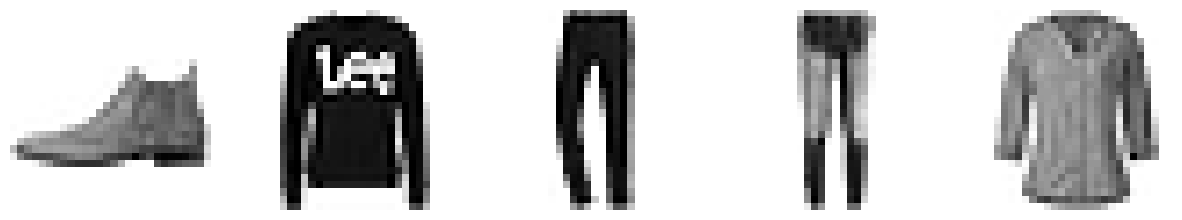

In [3]:
#

n_examples = 1000
example_images = x_test[0:n_examples]
example_labels = y_test[0:n_examples]

f, axs = plt.subplots(1, 5, figsize=(15, 4))
for j in range(len(axs)):
    axs[j].imshow(example_images[j], cmap='binary')
    axs[j].axis('off')

Encoder

In [19]:
#
def build_encoder():
    input_img = Input(shape=(28, 28, 1))
    x = Conv2D(8, (5, 5), activation='relu', padding='valid')(input_img)
    x = Conv2D(4, (5, 5), activation='relu', padding='valid')(x)
    encoded = Conv2D(2, (5, 5), activation='relu', padding='valid')(x)
    return Model(inputs=input_img, outputs=encoded)

encoder = build_encoder()


Prueba el decoder solo antes de entrenar, para ver variables lantentes sin aprendizaje.

Decoder

In [22]:
#
def build_decoder():
    encoded_input = Input(shape=(16, 16, 2))  # Adjusted to match encoder output
    x = Conv2DTranspose(4, (5, 5), activation='relu', padding='valid')(encoded_input)
    x = Conv2DTranspose(8, (5, 5), activation='relu', padding='valid')(x)
    decoded = Conv2DTranspose(1, (5, 5), activation='sigmoid', padding='valid')(x)

    # Cropping2D is no longer needed as dimensions match
    return Model(inputs=encoded_input, outputs=decoded)

decoder = build_decoder()

Integración de la arquitectura en autoencoder

In [23]:
#

autoencoder = Model(inputs=encoder.input, outputs=decoder(encoder.output))
autoencoder.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 24, 24, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 20, 20, 4)      │           804 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 2)      │           202 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_11 (Functional)      │ (None, 28, 28, 1)      │         1,213 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427 (9.48 KB)

 Trainable params: 2,427 (9.48 KB)

 Non-trainable params: 0 (0.00 B)

Comlpilación y Fit del autoencoder, todo entrena junto.

In [24]:

#
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

#
autoencoder.fit(x_train, x_train, epochs=5, batch_size=32,
                validation_data=(x_test, x_test))


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.4095 - val_loss: 0.3078
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.3025 - val_loss: 0.2962
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2932 - val_loss: 0.2921
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2881 - val_loss: 0.2885
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2854 - val_loss: 0.2858


Solo econder para generar variables latentes

In [26]:
#
posttrain_example_encodings = encoder(example_images).numpy()
posttrain_example_encodings = posttrain_example_encodings.reshape(-1, 16 * 16 * 2) # Corrected reshape dimension

Graficar variables latentes

<Axes: >

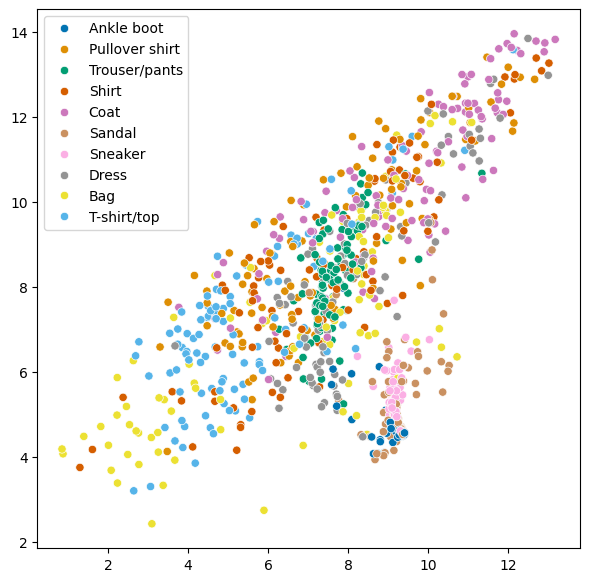

In [37]:
#
f, axs = plt.subplots(nrows=1, ncols=1, figsize=(7, 7))
sns.scatterplot(x=posttrain_example_encodings[:, 0],
                y=posttrain_example_encodings[:, 1],
                hue=class_names[example_labels], ax=axs,
                palette=sns.color_palette("colorblind", 10))


Autoencoder completo para reconstrucción de imágenes.

In [32]:
#

reconstructed_example_images = autoencoder.predict(example_images)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


Comparación de instacia original vs reconstruido. En este caso las variables latentes son toda la matriz (28,28,8), al ser más grande y poderosa si incluye detalles como marcas de la ropa.

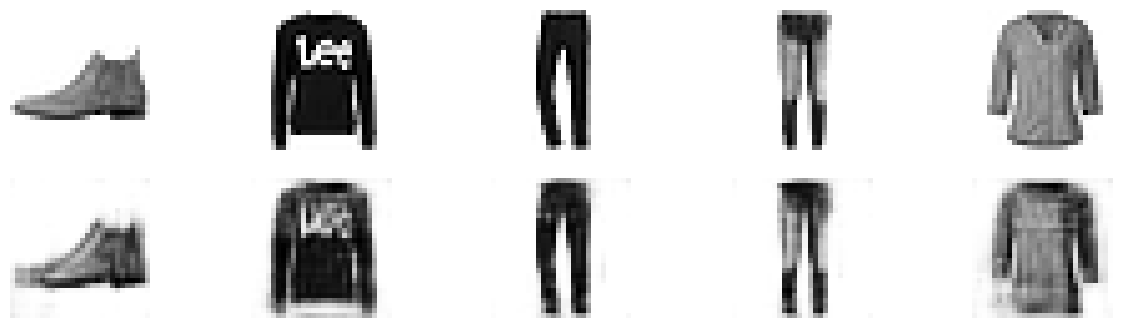

In [33]:
#
f, axs = plt.subplots(2, 5, figsize=(15, 4))
for j in range(5):
    axs[0, j].imshow(example_images[j].squeeze(), cmap='binary')
    axs[1, j].imshow(reconstructed_example_images[j].squeeze(), cmap='binary')
    axs[0, j].axis('off')
    axs[1, j].axis('off')